## 1. Objective

Before fitting ARIMA models, it is important to understand whether the time series is stationary and whether lagged values contain useful information.

This notebook focuses on three versions of the NZD/USD exchange-rate series:

- `DEXUSNZ`: the raw NZD/USD exchange-rate level
- `log_nzd_usd`: the log-transformed exchange-rate level
- `nzd_usd_return`: the daily log return series

The main questions are:

1. Does the exchange-rate level appear stationary?
2. Do log returns appear more stationary than the level series?
3. Is there meaningful autocorrelation in the level or return series?
4. What does this imply for future ARIMA modeling?

## 2. Load processed dataset

This section loads the cleaned and transformed dataset created in the first notebook.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
plt.rcParams['figure.figsize'] = (15,7)

cleaned_data = pd.read_csv('/Users/masonwang/Documents/Projects/Time Series Analysis/NZD-USD-Exchange-Rate-Forecaster/data/processed/cleaned_nzd_usd.csv')
cleaned_data['observation_date'] = pd.to_datetime(cleaned_data.observation_date)

In [3]:
cleaned_data.head()

,observation_date,DEXUSNZ,log_nzd_usd,nzd_usd_return
0,2016-06-06,0.6931,-0.366581,NaN
1,2016-06-07,0.6981,-0.359393,0.007188
2,2016-06-08,0.7024,-0.353252,0.006141
3,2016-06-09,0.7133,-0.337853,0.015399
4,2016-06-10,0.7069,-0.346866,-0.009013


In [4]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2498 entries, 0 to 2497
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  2498 non-null   datetime64[us]
 1   DEXUSNZ           2498 non-null   float64       
 2   log_nzd_usd       2498 non-null   float64       
 3   nzd_usd_return    2497 non-null   float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 78.2 KB


In [5]:
cleaned_data.shape

(2498, 4)

The processed NZD/USD dataset was loaded successfully. The date column was converted to a datetime type and the observations were sorted chronologically.

## 3. Visual comparison of level, log level, and returns

This section visually compares the raw exchange-rate level, the log exchange rate, and daily log returns.

Text(0, 0.5, 'NZD to USD Exchange Rate')

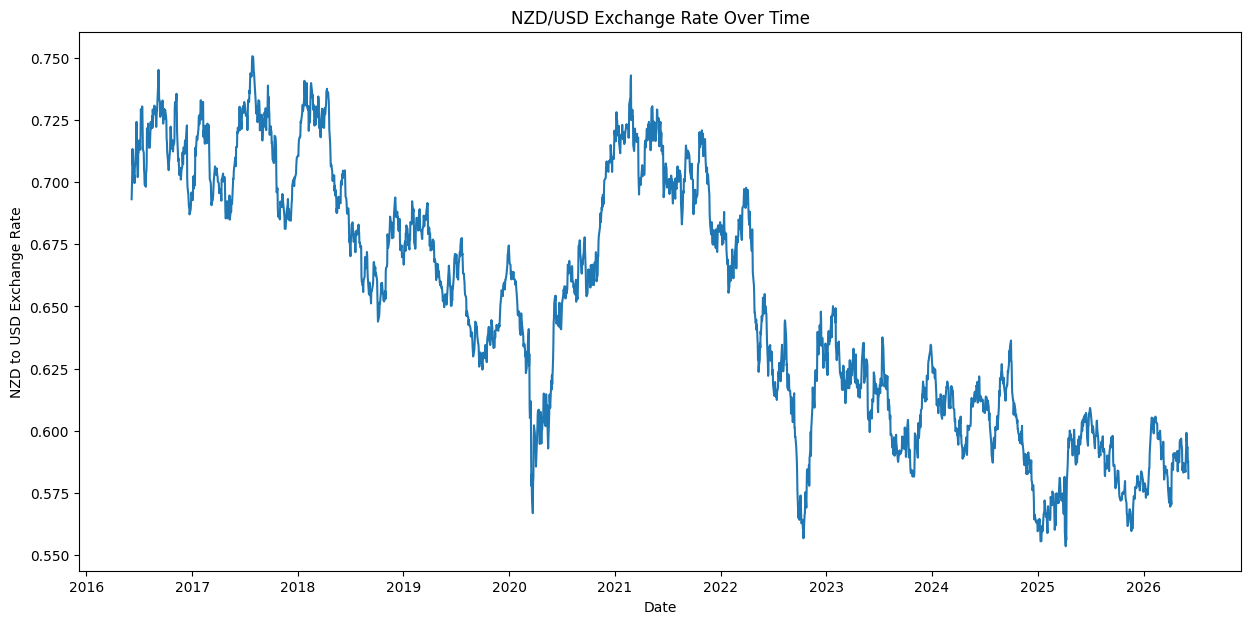

In [6]:
plt.plot(cleaned_data.observation_date,cleaned_data.DEXUSNZ)
plt.title('NZD/USD Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('NZD to USD Exchange Rate')


Text(0.5, 0, 'Date')

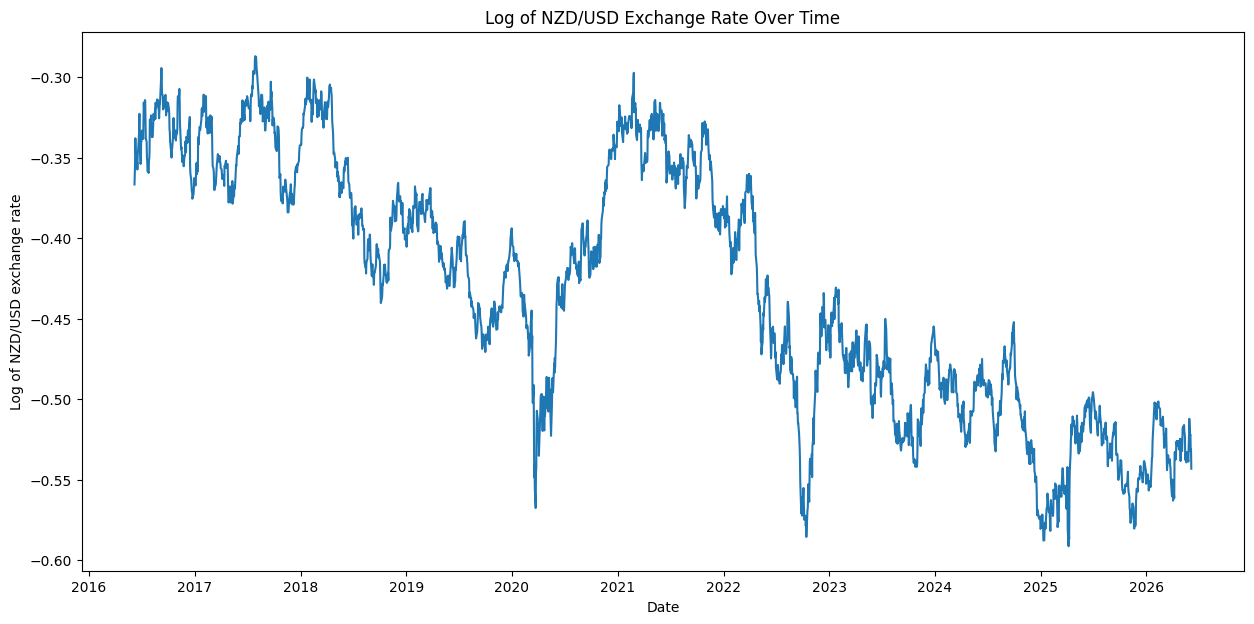

In [7]:
plt.plot(cleaned_data.observation_date,cleaned_data.log_nzd_usd)
plt.title('Log of NZD/USD Exchange Rate Over Time')
plt.ylabel('Log of NZD/USD exchange rate')
plt.xlabel('Date')

Text(0.5, 0, 'Date')

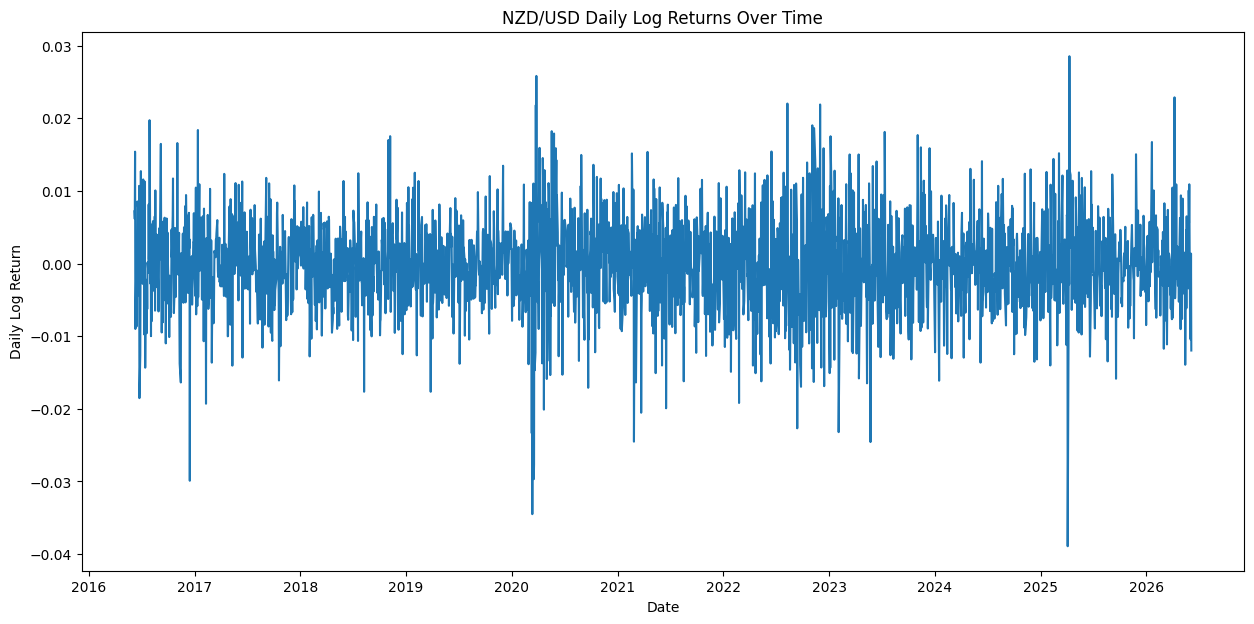

In [8]:
plt.plot(cleaned_data.observation_date,cleaned_data.nzd_usd_return)
plt.title('NZD/USD Daily Log Returns Over Time')
plt.ylabel('Daily Log Return')
plt.xlabel('Date')

The exchange-rate level and log exchange-rate level show persistent movement over time, while the return series fluctuates around zero. This suggests that the level series may be nonstationary, while the return series may be closer to stationary.

## 4. Autocorrelation analysis

This section uses autocorrelation plots to examine whether the NZD/USD exchange-rate series is related to its own past values. Autocorrelation helps identify whether lagged values may contain useful information for forecasting.

<Figure size 1200x500 with 0 Axes>

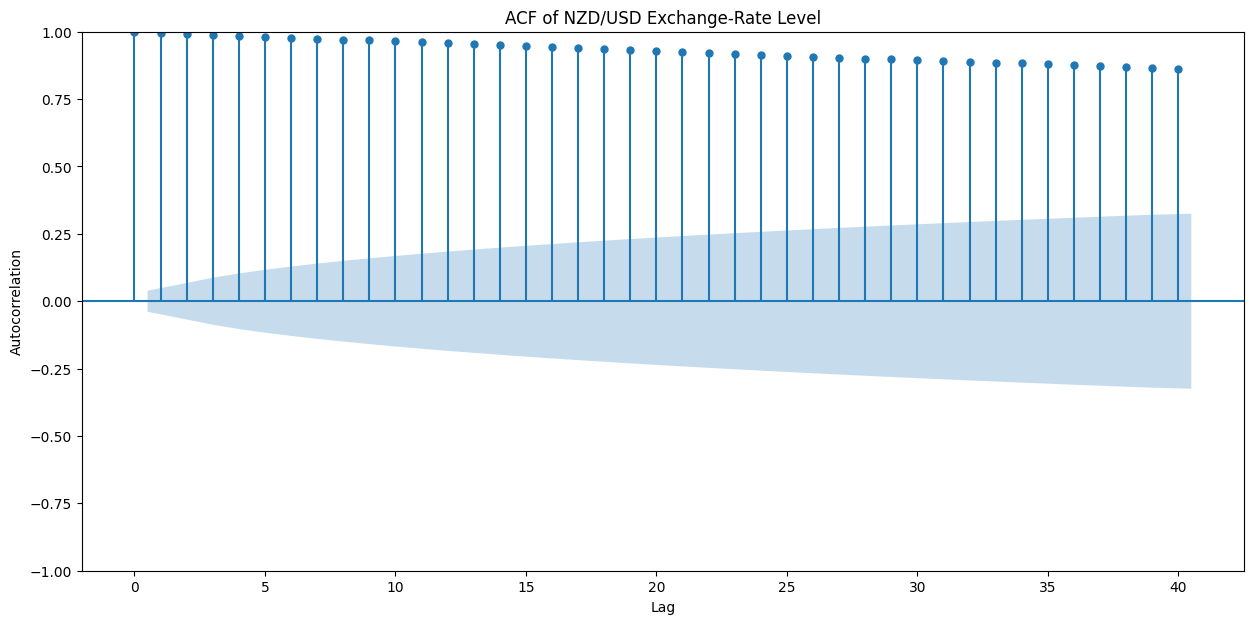

In [9]:
from statsmodels.graphics.tsaplots import plot_acf
plt.figure(figsize=(12, 5))

level_series = cleaned_data['DEXUSNZ']
plot_acf(level_series, lags=40)
plt.title('ACF of NZD/USD Exchange-Rate Level')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()

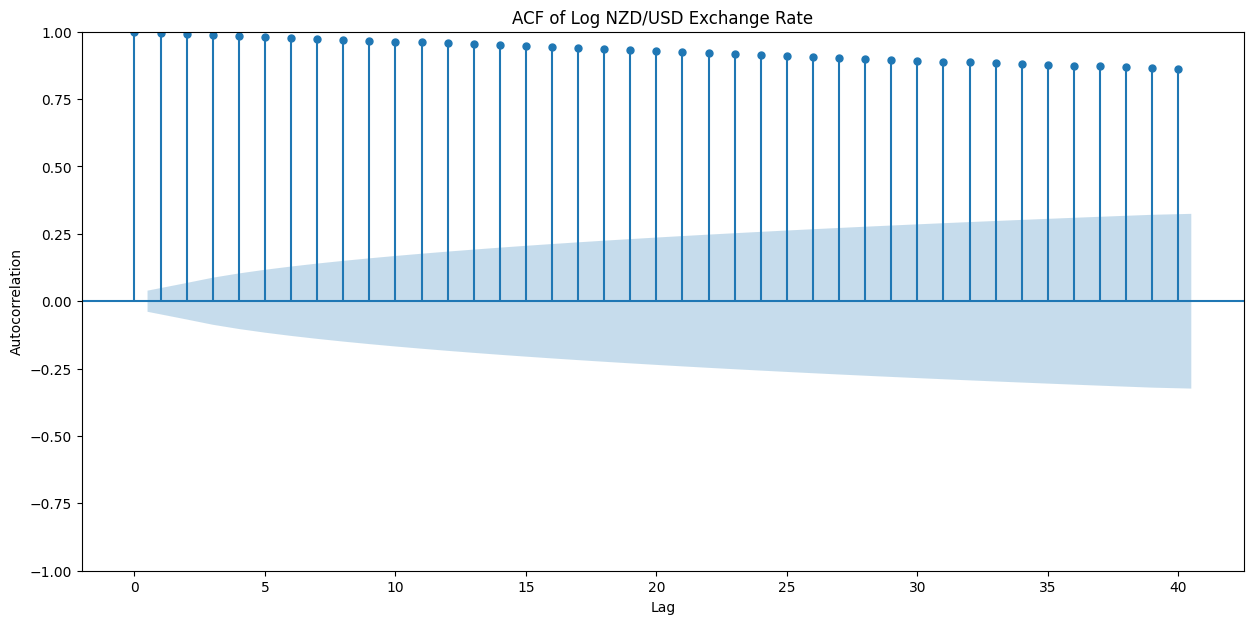

In [10]:
log_series = cleaned_data['log_nzd_usd']
plot_acf(log_series, lags=40)
plt.title('ACF of Log NZD/USD Exchange Rate')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()

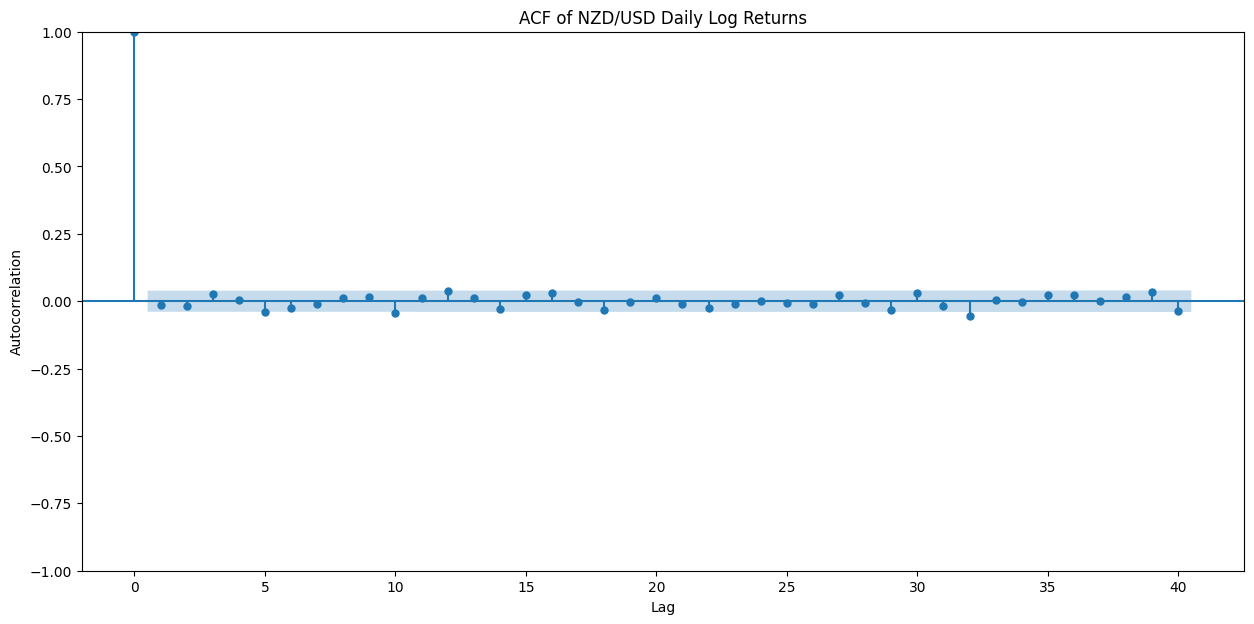

In [11]:
return_series = cleaned_data['nzd_usd_return'].dropna()
plot_acf(return_series, lags=40)
plt.title('ACF of NZD/USD Daily Log Returns')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()

The ACF plots show a clear difference between the exchange-rate level series and the return series. Both `DEXUSNZ` and `log_nzd_usd` have very high autocorrelation that decays slowly across the first 40 lags, which suggests strong persistence and possible nonstationarity. In contrast, the `nzd_usd_return` ACF is much closer to zero across most lags, suggesting that daily log returns have limited linear dependence on their own recent history.

This supports the idea that future ARIMA-style modeling should be careful about using the raw level series directly. Modeling differences or returns may be more appropriate than modeling the exchange-rate level without transformation.

## 5. Augmented Dickey-Fuller stationarity test

This section uses the Augmented Dickey-Fuller test to formally test whether the NZD/USD level, log-level, and return series appear stationary.

The ADF test uses the following hypotheses:

- Null hypothesis: the series has a unit root and is nonstationary.
- Alternative hypothesis: the series is stationary.

A low p-value provides evidence against the null hypothesis.

In [13]:
from statsmodels.tsa.stattools import adfuller
def run_adf_test(series, series_name):
    cleaned_series = series.dropna()
    result = adfuller(cleaned_series)

    adf_statistic = result[0]
    p_value = result[1]
    critical_values = result[4]

    print(f'ADF test for {series_name}')
    print('-' * 40)
    print(f'ADF statistic: {adf_statistic:.4f}')
    print(f'p-value: {p_value:.4f}')

    print('Critical values:')
    for level, value in critical_values.items():
        print(f'  {level}: {value:.4f}')

    if p_value < 0.05:
        print('Conclusion: Reject the null hypothesis. The series appears stationary.')
    else:
        print('Conclusion: Fail to reject the null hypothesis. The series appears nonstationary.')

run_adf_test(cleaned_data['DEXUSNZ'],'NZD/USD exchange-rate level')
run_adf_test(cleaned_data['log_nzd_usd'],'Log NZD/USD exchange rate')
run_adf_test(cleaned_data['nzd_usd_return'],'NZD/USD daily log returns')

ADF test for NZD/USD exchange-rate level
----------------------------------------
ADF statistic: -1.8810
p-value: 0.3411
Critical values:
  1%: -3.4330
  5%: -2.8627
  10%: -2.5674
Conclusion: Fail to reject the null hypothesis. The series appears nonstationary.
ADF test for Log NZD/USD exchange rate
----------------------------------------
ADF statistic: -1.8808
p-value: 0.3412
Critical values:
  1%: -3.4330
  5%: -2.8627
  10%: -2.5674
Conclusion: Fail to reject the null hypothesis. The series appears nonstationary.
ADF test for NZD/USD daily log returns
----------------------------------------
ADF statistic: -50.6436
p-value: 0.0000
Critical values:
  1%: -3.4330
  5%: -2.8627
  10%: -2.5674
Conclusion: Reject the null hypothesis. The series appears stationary.


The ADF test results support the visual and autocorrelation analysis. The raw `DEXUSNZ` series and the `log_nzd_usd` series both have p-values above 0.05, so the test fails to reject the null hypothesis of a unit root. This suggests that the exchange-rate level and log-level series are nonstationary.

In contrast, the daily log return series has a very large negative ADF statistic and a p-value near zero, so the test rejects the null hypothesis. This suggests that the return series is stationary.

These results imply that future ARIMA-style modeling should not use the raw level series without differencing. Modeling returns or differenced log exchange rates is likely more appropriate.

In [28]:
def get_adf_result(series, series_name):
    cleaned_series = series.dropna()
    result = adfuller(cleaned_series)

    adf_statistic = result[0]
    p_value = result[1]

    if p_value < 0.05:
        conclusion = 'Stationary'
    else:
        conclusion = 'Not Stationary'

    return {
        'Series': series_name,
        'ADF Statistic': adf_statistic,
        'P-Value': p_value,
        'Stationarity Conclusion': conclusion
    }


adf_results = [
    get_adf_result(cleaned_data['DEXUSNZ'], 'NZD/USD exchange-rate level'),
    get_adf_result(cleaned_data['log_nzd_usd'], 'Log NZD/USD exchange rate'),
    get_adf_result(cleaned_data['nzd_usd_return'], 'NZD/USD daily log returns')
]

adf_results_table = pd.DataFrame(adf_results)
adf_results_table

,Series,ADF Statistic,P-Value,Stationarity Conclusion
0,NZD/USD exchange-rate level,-1.880985,0.341059,Not Stationary
1,Log NZD/USD exchange rate,-1.880770,0.341161,Not Stationary
2,NZD/USD daily log returns,-50.643590,0.000000,Stationary


## 6. Modeling implications

The stationarity and autocorrelation results suggest that the raw `DEXUSNZ` level series and the `log_nzd_usd` level series should not be modeled directly without differencing. Both series show strong persistence in the ACF plots and fail the ADF stationarity test.

The `nzd_usd_return` series behaves differently. Its ACF values are much closer to zero, and the ADF test suggests that the return series is stationary. This makes the return series more appropriate for stationary time-series modeling.

For future ARIMA modeling, these results imply that there are two reasonable starting points:

1. Model the log exchange-rate level with differencing.
2. Model the daily log return series directly.

Because daily returns show weak autocorrelation, any forecasting model should still be compared carefully against the naïve and drift baselines from the previous notebook.

## 7. Final summary

This notebook examined the stationarity and autocorrelation properties of the NZD/USD exchange-rate series.

The exchange-rate level and log exchange-rate level both showed strong autocorrelation across many lags, indicating high persistence. The ADF test failed to reject nonstationarity for both level series.

The daily log return series showed much weaker autocorrelation, and the ADF test suggested that the return series is stationary. This supports using returns or differenced log exchange rates for future modeling rather than using the raw exchange-rate level directly.

The next notebook will use these findings to begin ARIMA-style modeling and compare model performance against the previously established baseline forecasts.